# Task 2: Data Analysis & Expoloratory Data Analysis (EDA)
**Project:** AI-Augmented Bussiness Analysis

**Author:** Sonia Mannnepuli

**Objective:** Load the e-commerence datasets, perform rigroius Exploatory Anaalysis (EDA), visualize core business metrics, and complie data-backend
opertaional insights.

In [2]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12,6)
plt.rcParams['font.size'] = 11
    
df_trends = pd.read_csv("/Users/Soniamannepuli/Downloads/revenue_trends.csv")
df_customer = pd.read_csv("/Users/Soniamannepuli/Downloads/customer_data.csv")
df_category = pd.read_csv("/Users/Soniamannepuli/Downloads/category_performance.csv")

df_trends['avg_order_value'] = (df_trends['monthly_revenue'] / df_trends['total_orders']).round(2)

print("--- Data sucessfully Loaded anbd Vertified! ---")
print(f"Loaded Trends Records: {len(df_trends)}")
print(f"Loaded Customer Records: {len(df_customer)}")
print(f"Loaded Category Records: {len(df_category)}")

--- Data sucessfully Loaded anbd Vertified! ---
Loaded Trends Records: 23
Loaded Customer Records: 3320
Loaded Category Records: 10


## 1. Trend Analysis 

- We examine month-over-month performance trends using two separate sequential line charts to isolate financial revenue
  growth from physical transactional volume.

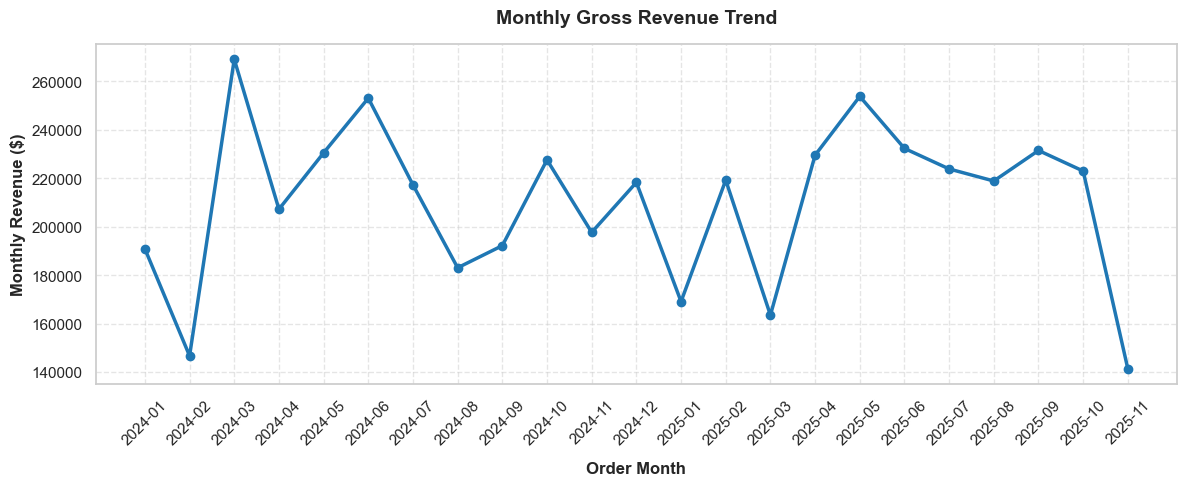

In [29]:
# Chart 1: Monthly Revenue Trend
# Set figure size
plt.figure(figsize=(12, 5))

# Plot line chart for Monthly Revenue
plt.plot(df_trends['order_month'], df_trends['monthly_revenue'], marker='o', color = '#1f77b4', linewidth=2.5)

# styling details
plt.title('Monthly Gross Revenue Trend', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Order Month', fontweight='bold', labelpad=10)
plt.ylabel('Monthly Revenue ($)', fontweight='bold')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha = 0.5)

# Save cahrt image file
plt.tight_layout()
plt.savefig('trend_revenue.png', dpi=100)
plt.show()

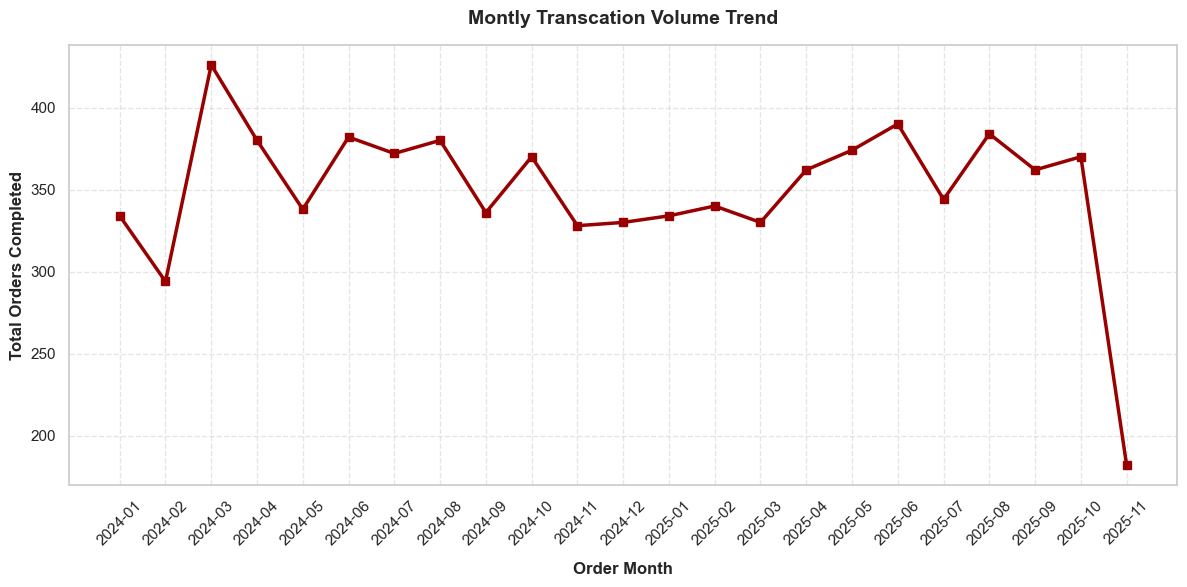

In [44]:
# Chart 2: Total Conmpleted Orders Trend
# Set the fig size

plt.figure(figsize=(12,6))

# Plot a another for the Total Orders
plt.plot(df_trends['order_month'], df_trends['total_orders'], marker = 's', color = '#990000', linewidth = 2.5)

# Styling details
plt.title('Montly Transcation Volume Trend', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Order Month', fontweight='bold', labelpad=10)
plt.ylabel('Total Orders Completed', fontweight='bold')
plt.xticks(rotation=45)
plt.grid(True, linestyle='dashed', alpha = 0.5)

# Save the chart file image
plt.tight_layout()
plt.savefig('trend_orders.png', dpi=100)
plt.show()


### **Trend Analysis Insights**
* **Aggregate Volume:** Across the entire operational period, the storefront generated a total gross revenue of **$4,839,425.16** over **8,042 successfully completed orders**.
* **Revenue Performance:** Monthly revenue shows strong operational stability, keeping a baseline average of **$210,409.79** per month.
* **Peak Performance Milestones:** March 2024 stands out as a historic performance peak on both charts, achieving **$269,139.06** in revenue alongside a record volume milestone of **426 orders**.
* **Volume Synchronicity:** Separating these graphs confirms that our revenue drops and peaks happen perfectly in step with our order volumes. This indicates that sales growth is currently driven by increasing transaction numbers rather than variations in average item prices.

## 2. Product & Category Performance Analysis
We evaluate the revenue contribution across different product categories to identify which areas drive business performance.

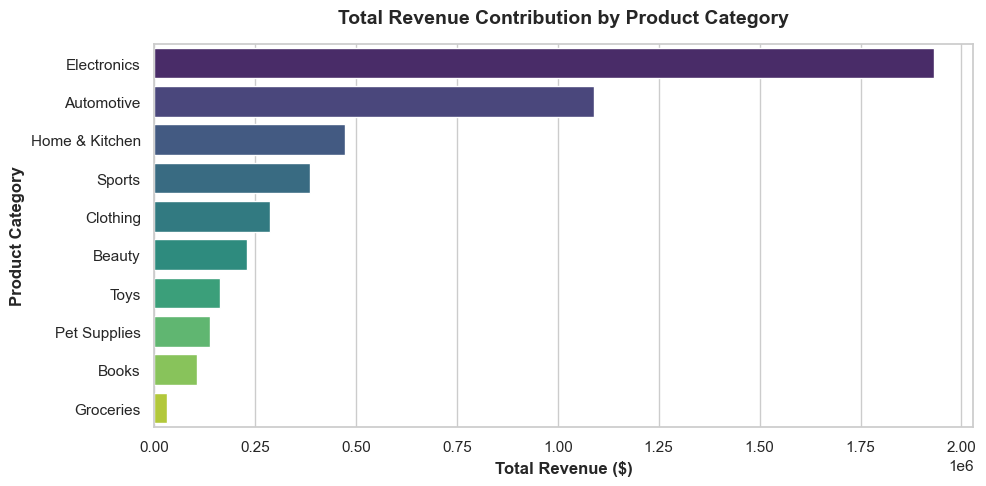

In [13]:
# Chart 3 - Category Revenue Bar Chart
# Set figure size
plt.figure(figsize=(10, 5))

# Plot a simple horizontal bar chart sorted by total revenue
sns.barplot(data=df_category, x='total_revenue', y='category', palette='viridis', hue='category', legend=False)

# Styling details
plt.title('Total Revenue Contribution by Product Category', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Total Revenue ($)', fontweight='bold')
plt.ylabel('Product Category', fontweight='bold')

# Save chart image file
plt.tight_layout()
plt.savefig('category_performance.png', dpi=100)
plt.show()


### **Product Category Insights**
* **Primary Core Driver:** The **Electronics** category stands out as the dominant driver of growth, accounting for a total of **$1,932,679.21** in revenue.
* **Secondary Core Driver:** The **Automotive** category represents the second largest segment, contributing **$1,089,906.76** to gross revenue.
* **Long-Tail Categories:** Lower volume categories include **Groceries** (**$33,226.48**) and **Books** (**$106,356.28**), showing opportunities for either niche marketing or portfolio optimization.

## 4. Distribution Analysis (Customer Spending Patterns)
We display a histogram of total user spending to observe the frequency distribution of Customer Lifetime Value (LTV).


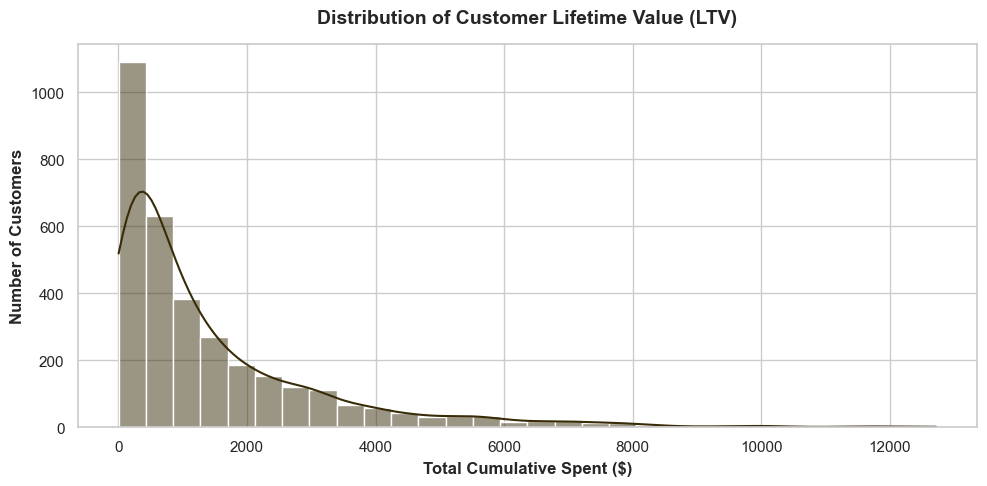

In [3]:
## Chart 4 -  Customer Spending Histogram
# Set figure size
plt.figure(figsize=(10, 5))

# Plot simple distribution histogram with a kernel density estimator (KDE) line
sns.histplot(data=df_customer, x='total_spent', bins=30, kde=True, color='#382C08')

# Styling details
plt.title('Distribution of Customer Lifetime Value (LTV)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Total Cumulative Spent ($)', fontweight='bold')
plt.ylabel('Number of Customers', fontweight='bold')

# Save chart image file
plt.tight_layout()
plt.savefig('customer_spending_distribution.png', dpi=300)
plt.show()


### **Distribution Analysis Insights**
* **Skewed Buying Distribution:** The customer spending distribution is strongly skewed to the right. This indicates a high volume of transactional users making smaller base purchases.
* **Long-Tail Spenders:** A significant tail extending toward higher spending amounts represents premium high-value customers. The maximum single-customer lifetime spend reaches **$12,720.22**, while the median spending stands at **$804.57**.
CELL 13: [Markdown Cell] — Heading for Segmentation Analysis


## 3. Customer Segmentation Analysis
We group users based on their spending levels into explicit behavioral tiers to structure target groups for strategic campaigns:
* **Bronze:** Spend $<$ \$500
* **Silver:** Spend between \$500 and \$2,000
* **Gold:** Spend $>$ \$2,000


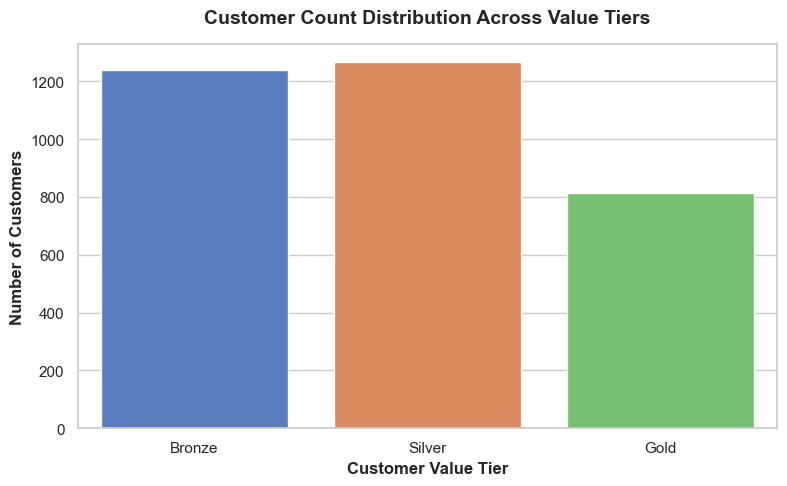

In [21]:
## Chart 5: Customer Segmentation Bar Chart
# Bin the customer total spending data into categorical segments
df_customer['segment'] = pd.cut(df_customer['total_spent'], 
                                 bins=[0, 500, 2000, float('inf')], 
                                 labels=['Bronze', 'Silver', 'Gold'])

# Set figure size
plt.figure(figsize=(8, 5))

# Plot the simple count distribution chart for segments
sns.countplot(data=df_customer, x='segment', order=['Bronze', 'Silver', 'Gold'], palette='muted', hue='segment', legend=False)

# Styling details
plt.title('Customer Count Distribution Across Value Tiers', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Customer Value Tier', fontweight='bold')
plt.ylabel('Number of Customers', fontweight='bold')

# Save chart image file
plt.tight_layout()
plt.savefig('customer_segmentation_counts.png', dpi=300)
plt.show()


### **Customer Segmentation Insights**
* **Tier Volumetrics:** * **Silver Customers** comprise the largest single customer cohort with **1,267 individuals**, generating **$1,361,729.78** in cumulative value.
  * **Bronze Customers** account for **1,238 individuals**, contributing **$270,870.98** in baseline value.
  * **Gold Customers** include **815 high-value individuals**. Despite being the smallest group by count, they contribute a massive **$3,206,824.40**, which is approximately **66.3%** of all generated sales revenue.
* **Strategic Growth Action:** Retaining the **Gold** cohort is vital for business health. Promotional strategy should focus on moving **Silver** level accounts into the **Gold** bracket through tier-based purchase incentives and loyalty rewards.